# TC50 O2 vs Concentration Plots

This notebook creates 2D plots of O2 percentage vs drug concentration at specific time points.

**Purpose:** Visualize dose-response relationships at critical time points to identify TC50 (concentration at 50% O2 response).

**Data Source:** `Cleaned_Data/DrugScreen19.11.25_compiled_O2_mean.xlsx`

**Target Drugs & Time Points:**
- Sunitinib: 32, 35 hrs
- Daunorubicin: 27, 30, 32 hrs
- Erlotinib: 22, 24, 27 hrs
- Vandetanib: 14, 27, 40 hrs
- Epirubicin: 24, 30 hrs

**Output:** One figure per drug with subplots for each time point showing O2 vs concentration.

In [12]:
# Cell #1
# Purpose: Setup and Imports

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [13]:
# Cell #2
# Depends on: 1
# Purpose: Path Configuration

current_dir = Path.cwd()

if current_dir.name == 'Prediction_Models':
    PROJECT_ROOT = current_dir.parent
elif (current_dir / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / 'EQN_Coefficients').exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Define paths
DATA_PATH = PROJECT_ROOT / 'Cleaned_Data' / 'DrugScreen19.11.25_compiled_O2_mean.xlsx'
OUTPUT_DIR = PROJECT_ROOT / 'Output' / 'TC50_Plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Data file: {DATA_PATH}")
print(f"  {'[FOUND]' if DATA_PATH.exists() else '[NOT FOUND - CHECK PATH]'}")
print(f"✓ Output directory: {OUTPUT_DIR}")

✓ Project root: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO
✓ Data file: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Cleaned_Data\DrugScreen19.11.25_compiled_O2_mean.xlsx
  [FOUND]
✓ Output directory: c:\Users\NoahB\Documents\HebrewU Bioengineering\Cardiac_RODEO\Output\TC50_Plots


In [14]:
# Cell #3
# Depends on: 1, 2
# Purpose: Drug Configuration

DRUG_CONFIG = {
    'Sunitinib': {
        'timepoints': [35],
        'color': '#E63946'
    },
    'Daunorubicin': {
        'timepoints': [32],
        'color': '#F77F00'
    },
    'Erlotinib': {
        'timepoints': [24],
        'color': '#06AED5'
    },
    'Vandetanib': {
        'timepoints': [24],
        'color': '#8338EC'
    },
    'Epirubicin': {
        'timepoints': [22,24,27,30],
        'color': '#2A9D8F'
    }
}

print("📋 Drug Configuration:")
for drug, config in DRUG_CONFIG.items():
    timepoints_str = ', '.join([f"{t}h" for t in config['timepoints']])
    print(f"  {drug:15s}: {timepoints_str}")

print(f"\n✓ Total drugs: {len(DRUG_CONFIG)}")
print(f"✓ Total plots: {sum(len(cfg['timepoints']) for cfg in DRUG_CONFIG.values())}")

📋 Drug Configuration:
  Sunitinib      : 35h
  Daunorubicin   : 32h
  Erlotinib      : 24h
  Vandetanib     : 24h
  Epirubicin     : 22h, 24h, 27h, 30h

✓ Total drugs: 5
✓ Total plots: 8


In [15]:
# Cell #4
# Depends on: 1, 2
# Purpose: Load O2 data from multi-sheet Excel file

print("Loading O2 data from multiple sheets...\n")

xl_file = pd.ExcelFile(DATA_PATH)
print("📋 Available sheets in Excel file:")
for sheet in xl_file.sheet_names:
    print(f"  - {sheet}")

print("\n" + "="*80 + "\n")

drug_data = {}

def parse_first_row_time_first_col_conc(df_sheet):
    """
    Expected layout per sheet:
    - Row 0 (col 1+): time points (hours)
    - Col 0 (row 1+): concentrations (mM)
    - Data block: rows 1+, cols 1+ = O2 values
    """
    time_row = df_sheet.iloc[0, 1:].dropna()
    time_points = time_row.astype(float).to_numpy()

    conc_col = df_sheet.iloc[1:, 0].dropna()
    concentrations = conc_col.astype(float).to_numpy()

    rows = len(concentrations)
    cols = len(time_points)
    o2_block = df_sheet.iloc[1:1+rows, 1:1+cols].to_numpy(dtype=float)

    return time_points, concentrations, o2_block

for sheet_name in xl_file.sheet_names:
    df_sheet = pd.read_excel(DATA_PATH, sheet_name=sheet_name, header=None)
    
    if 'O2_mean' in sheet_name or 'O2' in sheet_name:
        # Extract drug name from sheet name
        drug_name = sheet_name.replace(' O2_mean', '').replace('O2_mean', '').replace(' O2', '').replace('O2', '').strip()
        
        # If drug name is empty, try getting from first cell
        if pd.isna(drug_name) or drug_name == '':
            cell_val = df_sheet.iloc[0, 0]
            if pd.notna(cell_val):
                drug_name = str(cell_val).strip()
        
        print(f"📊 {drug_name}:")
        print(f"   Sheet: {sheet_name}")
        print(f"   Shape: {df_sheet.shape}")
        
        time_points, concentrations, o2_matrix = parse_first_row_time_first_col_conc(df_sheet)

        if len(time_points) == 0 or len(concentrations) == 0:
            print("   ⚠ No time points or concentrations detected; skipping sheet")
            continue
        
        print(f"   Time points ({len(time_points)}): {time_points[:8].tolist()}{'...' if len(time_points) > 8 else ''}")
        print(f"   Concentrations ({len(concentrations)}): {concentrations[:8].tolist()}{'...' if len(concentrations) > 8 else ''}")
        print(f"   O2 matrix shape: {o2_matrix.shape} (rows=concentrations, cols=time points)")
        
        drug_data[drug_name] = {
            'sheet_name': sheet_name,
            'time_points': time_points,
            'concentrations': concentrations,
            'o2_matrix': o2_matrix,
            'df_raw': df_sheet
        }
        print(f"   ✓ Loaded successfully\n")

print("="*80)
print(f"\n✓ Loaded {len(drug_data)} drug sheets")
print(f"✓ Drugs found: {list(drug_data.keys())}")

# Store for later use - this is a dictionary!
df_o2_raw = drug_data


Loading O2 data from multiple sheets...

📋 Available sheets in Excel file:
  - All_Drugs
  - Amiodarone O2_mean
  - Bortezomib O2_mean
  - Chlorpromazine O2_mean
  - Cobimetinib O2_mean
  - Dactinomycin O2_mean
  - Daunorubicin of O2_mean
  - Doxorubicin O2_mean
  - Epirubicin O2_mean
  - Erlotinib O2_mean
  - Etomoxir O2_mean
  - Gemcitibine O2_mean
  - Ibrutinib O2_mean
  - Ibuprofen O2_mean
  - Isoproterenol O2_mean
  - Mexiletine O2_mean
  - Nifedipine O2_mean
  - Panobinostat O2_mean
  - Plicamycin O2_mean
  - Rosiglitazone O2_mean
  - Sotalol O2_mean
  - Sunitinib O2_mean
  - Vandetanib O2_mean
  - Vincristine O2_mean
  - Vioxx O2_mean
  - Vorinostat O2_mean


📊 Amiodarone:
   Sheet: Amiodarone O2_mean
   Shape: (26, 33)
   Time points (32): [3.0, 7.0, 18.0, 21.0, 24.0, 26.0, 29.0, 31.0]...
   Concentrations (25): [10.0, 10.0, 5.0, 5.0, 5.0, 2.5, 2.5, 2.5]...
   O2 matrix shape: (25, 32) (rows=concentrations, cols=time points)
   ✓ Loaded successfully

📊 Bortezomib:
   Sheet: Bor

## Data Structure Analysis

**After running the cell above, examine the data structure:**
- Each drug is loaded from its corresponding sheet (e.g., "Sunitinib O2_mean")
- `drug_data[drug_name]` contains: time_points, concentrations, o2_matrix
- `o2_matrix[i, j]` = O2 value at concentration[i] and time_points[j]

In [16]:
# Cell #5
# Depends on: 1, 4
# Purpose: Helper Functions

def get_drug_data(drug_name: str, drug_data_dict: dict) -> Optional[dict]:
    """
    Get data dictionary for a specific drug (case-insensitive, partial match fallback).
    Data layout: time_points along columns, concentrations along rows (o2_matrix[row, col]).
    """
    # Exact match first
    if drug_name in drug_data_dict:
        return drug_data_dict[drug_name]
    
    # Case-insensitive match
    for key in drug_data_dict.keys():
        if key.lower() == drug_name.lower():
            return drug_data_dict[key]
    
    # Partial match (drug name contains or is contained in key)
    for key in drug_data_dict.keys():
        if drug_name.lower() in key.lower() or key.lower() in drug_name.lower():
            print(f"   ⚠ Using partial match: '{key}' for '{drug_name}'")
            return drug_data_dict[key]
    
    return None


def align_o2_matrix(drug_dict: dict) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Ensure matrix dims match concentrations (rows) and time_points (cols).
    Returns trimmed/aligned (concentrations, time_points, o2_matrix).
    """
    time_points = np.asarray(drug_dict['time_points'], dtype=float)
    concentrations = np.asarray(drug_dict['concentrations'], dtype=float)
    o2_matrix = np.asarray(drug_dict['o2_matrix'], dtype=float)

    rows = min(len(concentrations), o2_matrix.shape[0])
    cols = min(len(time_points), o2_matrix.shape[1])

    if (rows, cols) != o2_matrix.shape:
        o2_matrix = o2_matrix[:rows, :cols]
        time_points = time_points[:cols]
        concentrations = concentrations[:rows]
        print(f"   ℹ Adjusted matrix to {o2_matrix.shape} to align with rows/cols")

    return concentrations, time_points, o2_matrix


def get_o2_at_timepoint(drug_dict: dict, target_time: float, tolerance: float = 1.0) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract concentration and O2 response arrays for a specific time point.
    """
    concentrations, time_points, o2_matrix = align_o2_matrix(drug_dict)
    
    # Find closest time point
    time_diffs = np.abs(time_points - target_time)
    closest_idx = np.argmin(time_diffs)
    
    if time_diffs[closest_idx] > tolerance:
        print(f"   ⚠ No time point within {tolerance}h of {target_time}h")
        print(f"      Closest: {time_points[closest_idx]}h (diff: {time_diffs[closest_idx]:.1f}h)")
        return np.array([]), np.array([])
    
    actual_time = time_points[closest_idx]
    if actual_time != target_time:
        print(f"   ℹ Using {actual_time}h (closest to {target_time}h)")
    
    # Extract O2 values at this time point
    o2_values = o2_matrix[:, closest_idx]
    
    return concentrations, o2_values


def calculate_tc50(concentrations: np.ndarray, responses: np.ndarray) -> Optional[float]:
    """
    Calculate TC50 (concentration at 50% response) via linear interpolation.
    """
    if len(concentrations) < 2 or len(responses) < 2:
        return None
    
    # Remove NaN values
    mask = ~(np.isnan(concentrations) | np.isnan(responses))
    conc = concentrations[mask]
    resp = responses[mask]
    
    if len(conc) < 2:
        return None
    
    # Sort by concentration
    sort_idx = np.argsort(conc)
    conc = conc[sort_idx]
    resp = resp[sort_idx]
    
    # Assume baseline is maximum response (at lowest concentration)
    baseline = np.max(resp)
    target = baseline * 0.5
    
    # Find where response crosses 50% threshold
    if resp.min() > target or resp.max() < target:
        return None  # TC50 outside measured range
    
    # Linear interpolation
    tc50 = np.interp(target, resp[::-1], conc[::-1])  # Reverse for decreasing response
    
    return tc50


def sanitize_filename(name: str) -> str:
    """Remove invalid filename characters."""
    return name.replace('/', '_').replace('\\', '_').replace(' ', '_').replace(':', '_')


print("✓ Helper functions defined")


✓ Helper functions defined


## Example: Single Drug/Time Point Plot

Test the plotting workflow with one drug and one time point.

Creating example plot: Epirubicin at 24h

✓ Found data for Epirubicin
  Time points: [ 0.  4.  6.  9. 12. 14. 17. 19. 22. 24.]...
  Concentrations: [12. 12.  6.  6.  6.]...
  O2 matrix shape: (19, 37) (rows=conc, cols=time)
✓ Found 19 concentration points at 24h

✓ Sigmoid TC50 = 6.389 mM


C:\Users\NoahB\AppData\Local\Temp\ipykernel_24872\206157001.py:104: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\NoahB\AppData\Local\Temp\ipykernel_24872\206157001.py:106: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)


💾 Saved: EXAMPLE_Epirubicin_24h_sigmoid.png


c:\Users\NoahB\miniconda3\envs\jupyter-ai-claude\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


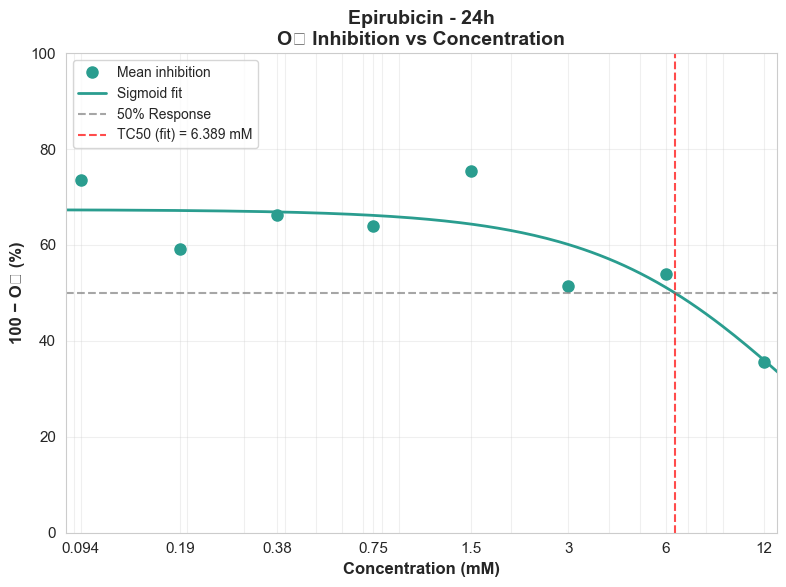

In [17]:
# Cell #6
# Depends on: 1, 3, 4, 5
# Purpose: Example - Single Drug/Time Point Plot (log x-axis, 100−O₂, sigmoid fit)

from scipy.optimize import curve_fit

EXAMPLE_DRUG = 'Epirubicin'
EXAMPLE_TIME = 24  # hours

print(f"Creating example plot: {EXAMPLE_DRUG} at {EXAMPLE_TIME}h\n")

drug_info = get_drug_data(EXAMPLE_DRUG, df_o2_raw)

if drug_info is None:
    print(f"⚠ No data found for {EXAMPLE_DRUG}.")
    print(f"  Available drugs: {list(df_o2_raw.keys())}")
else:
    print(f"✓ Found data for {EXAMPLE_DRUG}")
    print(f"  Time points: {drug_info['time_points'][:10]}...")
    print(f"  Concentrations: {drug_info['concentrations'][:5]}...")
    print(f"  O2 matrix shape: {drug_info['o2_matrix'].shape} (rows=conc, cols=time)")
    
    concentrations, o2_values = get_o2_at_timepoint(drug_info, EXAMPLE_TIME)
    
    if len(concentrations) == 0:
        print(f"⚠ No data at {EXAMPLE_TIME}h.")
    else:
        print(f"✓ Found {len(concentrations)} concentration points at {EXAMPLE_TIME}h")
        
        df_plot = pd.DataFrame({'Concentration': concentrations, 'O2': o2_values})
        df_avg = df_plot.groupby('Concentration', as_index=False).mean()
        df_avg = df_avg.sort_values('Concentration')
        df_avg['Inhibition'] = 85 - df_avg['O2']
        
        if (df_avg['Concentration'] <= 0).any():
            print("   ℹ Dropped non-positive concentrations for log-scale plotting.")
        df_plot_log = df_avg[df_avg['Concentration'] > 0].copy()
        
        if df_plot_log.empty:
            print("⚠ Cannot plot on log scale because all concentrations are ≤ 0.")
        else:
            x_conc = df_plot_log['Concentration'].to_numpy()
            y_inhib = df_plot_log['Inhibition'].to_numpy()
            x_log = np.log10(x_conc)
            
            fig, ax = plt.subplots(figsize=(8, 6))
            # Scatter markers only
            ax.plot(x_conc, y_inhib, 'o',
                    markersize=8,
                    color=DRUG_CONFIG[EXAMPLE_DRUG]['color'],
                    label='Mean inhibition')
            
            def logistic_curve(xlog, bottom, top, logEC50, slope):
                return bottom + (top - bottom) / (1 + np.exp((logEC50 - xlog) * slope))
            
            tc50_sigmoid = None
            try:
                if len(x_log) >= 3:
                    p0 = [y_inhib.min(), y_inhib.max(), np.median(x_log), 1.0]
                    popt, _ = curve_fit(logistic_curve, x_log, y_inhib, p0=p0, maxfev=20000)
                    
                    x_smooth = np.linspace(x_log.min() - 0.2, x_log.max() + 0.2, 200)
                    conc_smooth = 10 ** x_smooth
                    y_smooth = logistic_curve(x_smooth, *popt)
                    ax.plot(conc_smooth, y_smooth, '-',
                            color=DRUG_CONFIG[EXAMPLE_DRUG]['color'],
                            linewidth=2, label='Sigmoid fit')
                    
                    bottom, top, logEC50, slope = popt
                    denom = top - bottom
                    target = 50.0
                    if slope != 0 and denom != 0:
                        denom_target = target - bottom
                        if denom_target != 0:
                            ratio = denom / denom_target - 1.0
                            if ratio > 0:
                                tc50_log = logEC50 - (1.0 / slope) * np.log(ratio)
                                tc50_sigmoid = 10 ** tc50_log
            except Exception as err:
                print(f"   ⚠ Sigmoid fit failed: {err}")
                tc50_sigmoid = None
            
            if tc50_sigmoid is not None and np.isfinite(tc50_sigmoid):
                ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5,
                           alpha=0.7, label='50% Response')
                ax.axvline(x=tc50_sigmoid, color='red', linestyle='--', linewidth=1.5,
                           alpha=0.7, label=f'TC50 (fit) = {tc50_sigmoid:.3f} mM')
                print(f"\n✓ Sigmoid TC50 = {tc50_sigmoid:.3f} mM")
            else:
                print("\n⚠ Sigmoid TC50 could not be calculated (fit failed or outside range)")
            
            ax.set_xscale('log')
            ax.set_xticks(x_conc)
            ax.set_xticklabels([f"{x:.3g}" for x in x_conc])
            ax.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
            ax.set_ylabel('100 − O₂ (%)', fontsize=12, fontweight='bold')
            ax.set_title(f"{EXAMPLE_DRUG} - {EXAMPLE_TIME}h\nO₂ Inhibition vs Concentration",
                         fontsize=14, fontweight='bold')
            ax.set_ylim(0, 100)
            ax.set_xlim(x_conc.min() * 0.9, x_conc.max() * 1.1)
            ax.grid(True, alpha=0.3, which='both')
            ax.legend(loc='best', fontsize=10)
            
            plt.tight_layout()
            save_path = OUTPUT_DIR / f"EXAMPLE_{sanitize_filename(EXAMPLE_DRUG)}_{EXAMPLE_TIME}h_sigmoid.png"
            plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
            print(f"💾 Saved: {save_path.name}")
            
            plt.show()


## Batch Processing: All Drugs and Time Points

Generate multi-panel figures for each drug showing all specified time points.

Generating TC50 plots for all drugs...


🔬 Sunitinib
   Time points: [35]
   💾 Saved panel figure: Sunitinib_sigmoid_panels.png


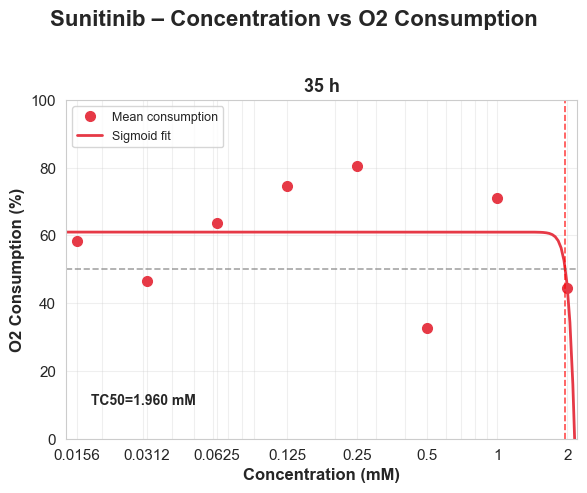


🔬 Daunorubicin
   Time points: [32]
   ⚠ Using partial match: 'Daunorubicin of' for 'Daunorubicin'
   💾 Saved panel figure: Daunorubicin_sigmoid_panels.png


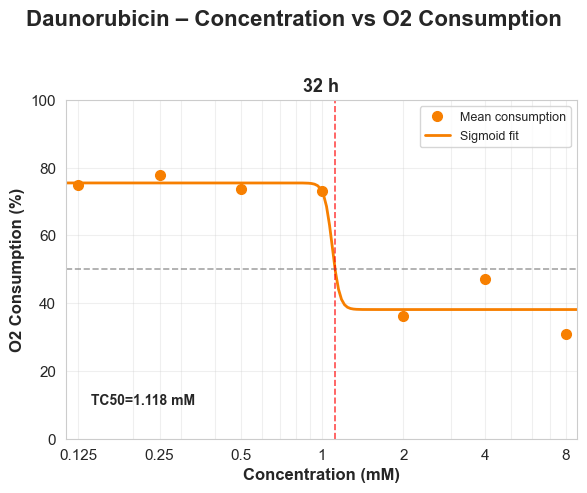


🔬 Erlotinib
   Time points: [24]
   💾 Saved panel figure: Erlotinib_sigmoid_panels.png


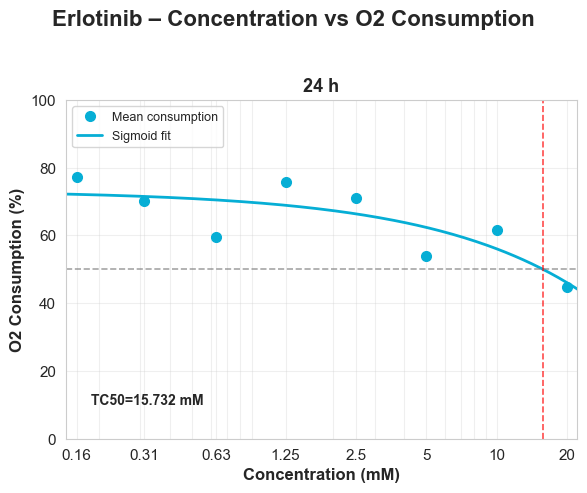


🔬 Vandetanib
   Time points: [24]
   💾 Saved panel figure: Vandetanib_sigmoid_panels.png


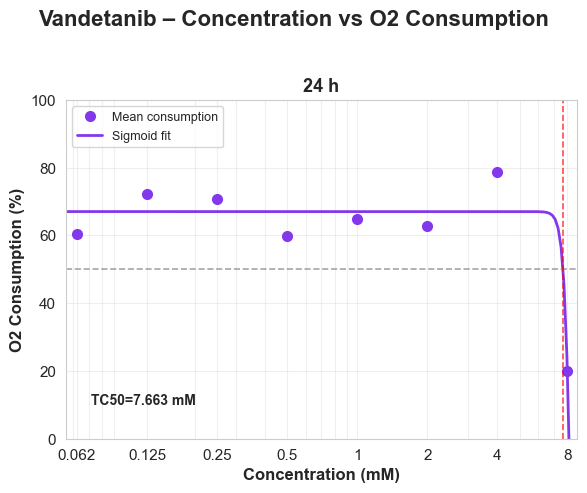


🔬 Epirubicin
   Time points: [22, 24, 27, 30]
   💾 Saved panel figure: Epirubicin_sigmoid_panels.png


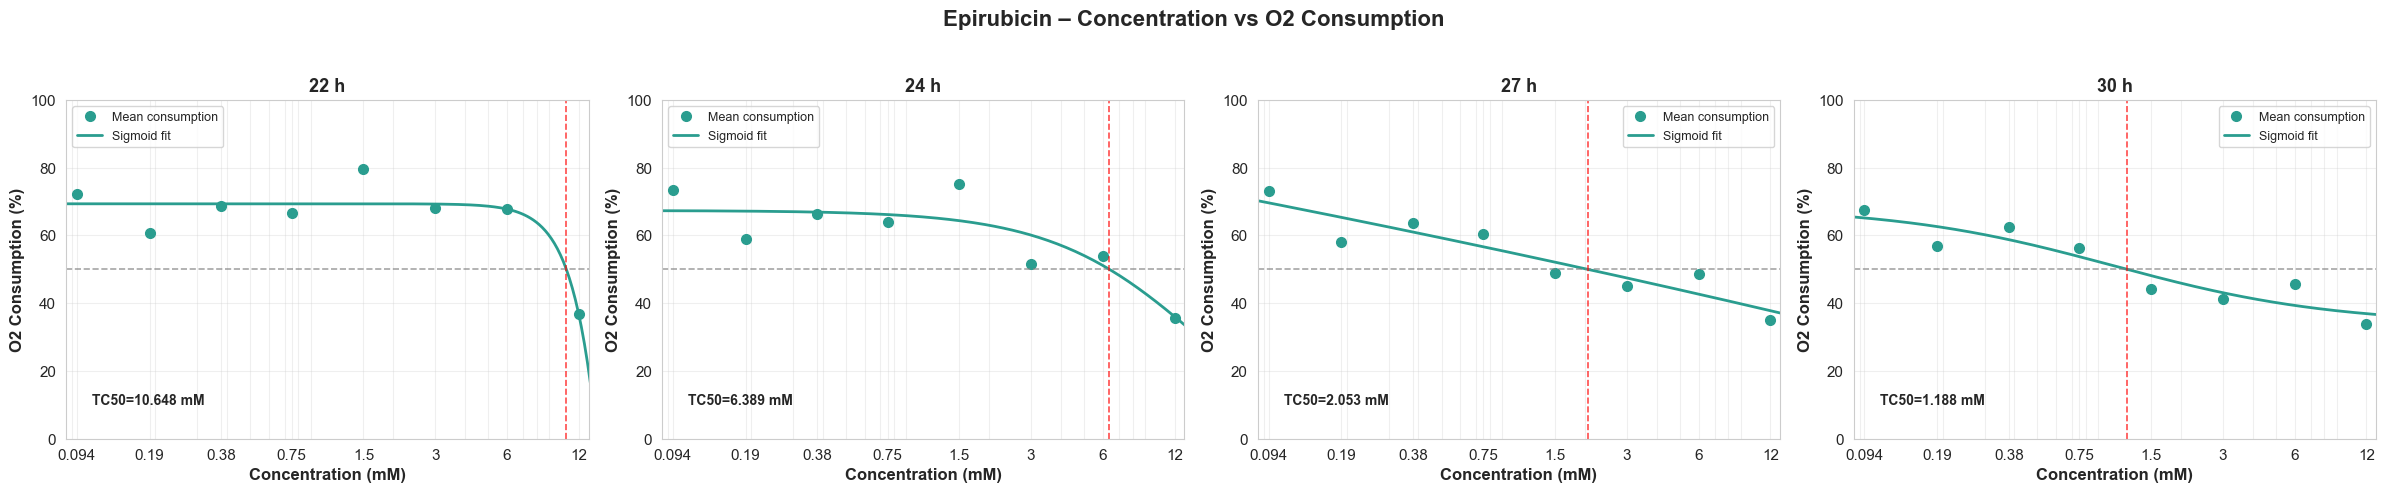

In [18]:
# Cell #7
# Depends on: 1, 2, 3, 4, 5
# Purpose: Batch Plotting – All Drugs with Sigmoidal Fits (log x-axis, 85−O₂)

from scipy.optimize import curve_fit

print("Generating TC50 plots for all drugs...\n")
print("=" * 80)

tc50_results = []

def logistic_curve(xlog, bottom, top, logEC50, slope):
    return bottom + (top - bottom) / (1 + np.exp((logEC50 - xlog) * slope))

for drug_name, config in DRUG_CONFIG.items():
    timepoints = config['timepoints']
    color = config['color']
    
    print(f"\n🔬 {drug_name}")
    print(f"   Time points: {timepoints}")

    drug_info = get_drug_data(drug_name, df_o2_raw)

    if drug_info is None:
        print("   ⚠ No data found (skipping)")
        continue
    
    fig, axes = plt.subplots(1, len(timepoints), figsize=(6 * len(timepoints), 5), squeeze=False)
    fig.suptitle(f"{drug_name} – Concentration vs O2 Consumption", fontsize=16, fontweight='bold')
    
    for ax, tp in zip(axes.flat, timepoints):
        conc, o2_vals = get_o2_at_timepoint(drug_info, tp)
        
        if len(conc) == 0:
            ax.text(0.5, 0.5, f"No data at {tp}h", ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        df_tp = pd.DataFrame({'Concentration': conc, 'O2': o2_vals})
        df_avg = df_tp.groupby('Concentration', as_index=False).mean().sort_values('Concentration')
        df_avg['Consumption'] = 85.0 - df_avg['O2']
        df_plot_log = df_avg[df_avg['Concentration'] > 0].copy()
        
        if df_plot_log.empty:
            ax.text(0.5, 0.5, "Non-positive concentrations only", ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue
        
        x_conc = df_plot_log['Concentration'].to_numpy()
        y_cons = df_plot_log['Consumption'].to_numpy()
        x_log = np.log10(x_conc)

        # Scatter points
        ax.plot(x_conc, y_cons, 'o', markersize=7, color=color, label='Mean consumption')
        
        tc50_fit = None
        try:
            if len(x_log) >= 3:
                p0 = [y_cons.min(), y_cons.max(), np.median(x_log), 1.0]
                popt, _ = curve_fit(logistic_curve, x_log, y_cons, p0=p0, maxfev=20000)
                x_smooth = np.linspace(x_log.min() - 0.2, x_log.max() + 0.2, 200)
                conc_smooth = 10 ** x_smooth
                y_smooth = logistic_curve(x_smooth, *popt)
                ax.plot(conc_smooth, y_smooth, '-', color=color, linewidth=2, label='Sigmoid fit')
                
                bottom, top, logEC50, slope = popt
                denom = top - bottom
                target = 50.0
                if slope != 0 and denom != 0:
                    denom_target = target - bottom
                    if denom_target != 0:
                        ratio = denom / denom_target - 1.0
                        if ratio > 0:
                            tc50_log = logEC50 - (1.0 / slope) * np.log(ratio)
                            tc50_fit = 10 ** tc50_log
        except Exception as err:
            print(f"   ⚠ Sigmoid fit failed at {tp}h: {err}")

        if tc50_fit is not None and np.isfinite(tc50_fit):
            ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
            ax.axvline(x=tc50_fit, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
            tc50_results.append({'Drug': drug_name, 'Time_h': tp, 'TC50_mM': tc50_fit})
            ax.text(0.05, 0.1, f"TC50={tc50_fit:.3f} mM", transform=ax.transAxes,
                    fontsize=10, fontweight='bold')
        else:
            ax.text(0.05, 0.1, "TC50 = N/A", transform=ax.transAxes,
                    fontsize=10, fontweight='bold')

        ax.set_xscale('log')
        ax.set_xticks(x_conc)
        ax.set_xticklabels([f"{x:.3g}" for x in x_conc])
        ax.set_xlabel('Concentration (mM)', fontsize=12, fontweight='bold')
        ax.set_ylabel('O2 Consumption (%)', fontsize=12, fontweight='bold')
        ax.set_title(f"{tp} h", fontsize=13, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.set_xlim(x_conc.min() * 0.9, x_conc.max() * 1.1)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='best', fontsize=9)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_path = OUTPUT_DIR / f"{sanitize_filename(drug_name)}_sigmoid_panels.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
    print(f"   💾 Saved panel figure: {save_path.name}")
    plt.show()


In [19]:
# Cell #8
# Depends on: 1, 7
# Purpose: TC50 Summary Table

if tc50_results:
    df_tc50 = pd.DataFrame(tc50_results)
    df_tc50 = df_tc50.sort_values(['Drug', 'Time_h']).reset_index(drop=True)
    
    print("\n" + "="*80)
    print("📊 TC50 SUMMARY")
    print("="*80 + "\n")
    
    display(df_tc50)
    
    # Save to CSV
    csv_path = OUTPUT_DIR / "TC50_summary.csv"
    df_tc50.to_csv(csv_path, index=False)
    print(f"\n💾 Summary saved: {csv_path.name}")
    
    # Statistics by drug
    print("\n" + "-"*80)
    print("TC50 Statistics by Drug:")
    print("-"*80)
    
    for drug in df_tc50['Drug'].unique():
        drug_data = df_tc50[df_tc50['Drug'] == drug]
        mean_tc50 = drug_data['TC50_mM'].mean()
        std_tc50 = drug_data['TC50_mM'].std()
        min_tc50 = drug_data['TC50_mM'].min()
        max_tc50 = drug_data['TC50_mM'].max()
        
        print(f"{drug:15s}: Mean={mean_tc50:.3f} ± {std_tc50:.3f} mM  [Range: {min_tc50:.3f}-{max_tc50:.3f}]")
else:
    print("\n⚠ No TC50 values calculated. Check data structure and helper functions.")


📊 TC50 SUMMARY



,Drug,Time_h,TC50_mM
0,Daunorubicin,32,1.117857
1,Epirubicin,22,10.647538
2,Epirubicin,24,6.389148
3,Epirubicin,27,2.052701
4,Epirubicin,30,1.187545
5,Erlotinib,24,15.732444
6,Sunitinib,35,1.960368
7,Vandetanib,24,7.662658



💾 Summary saved: TC50_summary.csv

--------------------------------------------------------------------------------
TC50 Statistics by Drug:
--------------------------------------------------------------------------------
Daunorubicin   : Mean=1.118 ± nan mM  [Range: 1.118-1.118]
Epirubicin     : Mean=5.069 ± 4.360 mM  [Range: 1.188-10.648]
Erlotinib      : Mean=15.732 ± nan mM  [Range: 15.732-15.732]
Sunitinib      : Mean=1.960 ± nan mM  [Range: 1.960-1.960]
Vandetanib     : Mean=7.663 ± nan mM  [Range: 7.663-7.663]


## Notes & Customization

### Data Structure

The Excel file contains multiple sheets, one per drug (e.g., "Sunitinib O2_mean").

Each sheet structure:
- Row 0: Drug name header
- Row 1: 'Scale' label, then time points starting at column 2
- Row 2+: Well info (col 0), concentrations (col 1), O2 values (cols 2+)

### TC50 Calculation

The `calculate_tc50()` function assumes:
- Baseline (100%) is the maximum O2 value (typically at lowest concentration)
- TC50 is where O2 drops to 50% of baseline
- Linear interpolation between measured points

### Troubleshooting

If plots show "No data" messages:
1. Check drug names match exactly (case-insensitive matching is supported)
2. Verify time points exist in the data (tolerance is ±1h)
3. Check the output of Cell 4 to see available drugs and time points

In [ ]:
# Cell #9
# Depends on: 1, 2, 3, 4, 5, 7
# Purpose: Save All Plotted Data to Excel

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Collecting all plotted data for Excel export...")
print("=" * 80)

# Create a timestamp
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Dictionary to store data for each drug
all_drug_data = {}

# Collect data for each drug and timepoint
for drug_name, config in DRUG_CONFIG.items():
    timepoints = config['timepoints']
    
    print(f"📊 Processing {drug_name}...")
    
    drug_info = get_drug_data(drug_name, df_o2_raw)
    
    if drug_info is None:
        print(f"   ⚠ No data found - skipping")
        continue
    
    # Create list to store all timepoint data for this drug
    drug_sheets = []
    
    for tp in timepoints:
        conc, o2_vals = get_o2_at_timepoint(drug_info, tp)
        
        if len(conc) == 0:
            print(f"   ⚠ No data at {tp}h - skipping")
            continue
        
        # Create DataFrame for this timepoint
        df_tp = pd.DataFrame({
            'Concentration_mM': conc,
            'O2_Percentage': o2_vals
        })
        
        # Calculate average by concentration
        df_avg = df_tp.groupby('Concentration_mM', as_index=False).mean()
        df_avg = df_avg.sort_values('Concentration_mM')
        df_avg['O2_Consumption'] = 85.0 - df_avg['O2_Percentage']
        df_avg['Timepoint_hours'] = tp
        
        # Find TC50 for this timepoint from results
        tc50_val = None
        for result in tc50_results:
            if result['Drug'] == drug_name and result['Time_h'] == tp:
                tc50_val = result['TC50_mM']
                break
        
        df_avg['TC50_mM'] = tc50_val if tc50_val is not None else np.nan
        df_avg['Timestamp'] = timestamp
        
        # Reorder columns
        df_avg = df_avg[['Timepoint_hours', 'Concentration_mM', 'O2_Percentage', 
                         'O2_Consumption', 'TC50_mM', 'Timestamp']]
        
        drug_sheets.append((tp, df_avg))
        print(f"   ✓ {tp}h: {len(df_avg)} concentration points")
    
    if drug_sheets:
        all_drug_data[drug_name] = drug_sheets

# Save to Excel with multiple sheets
if all_drug_data:
    excel_path = OUTPUT_DIR / f"TC50_PlotData_{datetime.now().strftime('%Y%m%d_%H%M%S')}.xlsx"
    
    print("\n" + "=" * 80)
    print(f"💾 Saving to Excel: {excel_path.name}")
    print("=" * 80)
    
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Create summary sheet first
        summary_rows = []
        for drug_name, sheets_list in all_drug_data.items():
            for tp, df_tp in sheets_list:
                tc50 = df_tp['TC50_mM'].iloc[0] if not df_tp['TC50_mM'].isna().all() else None
                summary_rows.append({
                    'Drug': drug_name,
                    'Timepoint_hours': tp,
                    'TC50_mM': tc50,
                    'Num_Concentrations': len(df_tp),
                    'Timestamp': timestamp
                })
        
        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name='Summary', index=False)
        print(f"\n   ✓ Summary sheet: {len(df_summary)} entries")
        
        # Create individual sheets for each drug/timepoint
        for drug_name, sheets_list in all_drug_data.items():
            for tp, df_tp in sheets_list:
                # Create sheet name: "DrugName_XXh"
                sheet_name = f"{drug_name}_{int(tp)}h"
                
                # Excel sheet names limited to 31 characters
                if len(sheet_name) > 31:
                    sheet_name = sheet_name[:31]
                
                df_tp.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"   ✓ {sheet_name}: {len(df_tp)} rows")
    
    print("\n" + "=" * 80)
    print(f"✅ Excel file saved successfully!")
    print(f"   Location: {excel_path}")
    print(f"   Total sheets: {1 + sum(len(sheets) for sheets in all_drug_data.values())}")
    print(f"   Timestamp: {timestamp}")
    print("=" * 80)
    
else:
    print("\n⚠ No data to save - check that plots were generated successfully")

SyntaxError: unterminated string literal (detected at line 76) (3889978080.py, line 76)